# WORK SPACE

## Baseline Autoencoder - Colon

In [5]:
#imports
import torch
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset

from src.models.autoencoder import AutoEncoder

In [27]:
# Load dataset
df = pd.read_csv("data/preprocessed/colon.csv")

# Keep only features
X = df.drop(columns=["label"])

# Convert to PyTorch tensor
X = torch.tensor(X.values, dtype=torch.float32)

# Create DataLoader
dataset = TensorDataset(X)
train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

print(X.shape)

torch.Size([62, 2000])


Tarining data is Ready

In [28]:
# Create model
input_dim = X.shape[1]
hidden_dim = 128

model = AutoEncoder(input_dim, hidden_dim)

# Loss function and optimizer
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=2000, out_features=128, bias=True)
    (1): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=2000, bias=True)
  )
)


Model, data, loss function, and optimizer are ready.

In [29]:
# Train model
num_epochs = 50
losses = []

model.train()

for epoch in range(num_epochs):
    epoch_loss = 0

    for (batch,) in train_loader:
        optimizer.zero_grad()

        output = model(batch)
        loss = criterion(output, batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 1/50, Loss: 2.4677
Epoch 2/50, Loss: 2.1801
Epoch 3/50, Loss: 1.8750
Epoch 4/50, Loss: 1.6145
Epoch 5/50, Loss: 1.4369
Epoch 6/50, Loss: 1.3305
Epoch 7/50, Loss: 1.2504
Epoch 8/50, Loss: 1.1925
Epoch 9/50, Loss: 1.1303
Epoch 10/50, Loss: 1.0656
Epoch 11/50, Loss: 1.0111
Epoch 12/50, Loss: 0.9527
Epoch 13/50, Loss: 0.9032
Epoch 14/50, Loss: 0.8682
Epoch 15/50, Loss: 0.8255
Epoch 16/50, Loss: 0.7910
Epoch 17/50, Loss: 0.7590
Epoch 18/50, Loss: 0.7297
Epoch 19/50, Loss: 0.7188
Epoch 20/50, Loss: 0.7444
Epoch 21/50, Loss: 0.8425
Epoch 22/50, Loss: 0.7831
Epoch 23/50, Loss: 0.7299
Epoch 24/50, Loss: 0.6711
Epoch 25/50, Loss: 0.6160
Epoch 26/50, Loss: 0.5964
Epoch 27/50, Loss: 0.5595
Epoch 28/50, Loss: 0.5281
Epoch 29/50, Loss: 0.5104
Epoch 30/50, Loss: 0.4898
Epoch 31/50, Loss: 0.4711
Epoch 32/50, Loss: 0.4546
Epoch 33/50, Loss: 0.4396
Epoch 34/50, Loss: 0.4278
Epoch 35/50, Loss: 0.4199
Epoch 36/50, Loss: 0.4031
Epoch 37/50, Loss: 0.3869
Epoch 38/50, Loss: 0.3715
Epoch 39/50, Loss: 0.

#### plot the loss

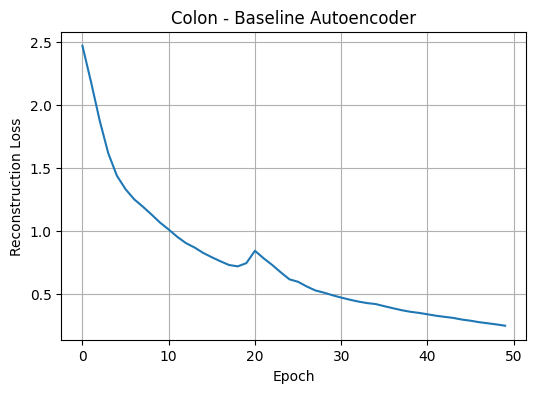

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Colon - Baseline Autoencoder")
plt.grid(True)

plt.savefig("reports/figures/colon_baseline_loss.png")
plt.show()

During the training of the baseline autoencoder, the reconstruction loss started at about **2.5** in the first epoch because the model had not learned anything yet. As the training continued, the loss decreased quickly during the first 10 epochs, showing that the model was learning the main patterns in the data. Between epochs 10 and 20, the loss continued to decrease but at a slower rate. Around epoch 20, there was a small increase in the loss, but this was only temporary, and the loss continued to decrease afterwards. By the end of 50 epochs, the reconstruction loss had reduced to about **0.25**, showing that the model had learned to reconstruct the input data much better. Overall, the model trained successfully and showed a steady improvement throughout the training process.


 - Loss plot generated successfully
 - Initial loss was apprix 2.5
 - Final loss approx 0.2
 - Stable convergance
 - No training instability
